In [1]:
import torch
import numpy as np
import os
import sys

sys.path.append("../src")
from train.ElmanRNN import *
import hidden_weights.HiddenWeightHelpers as hw  # plots, stats, norms, etc
import hidden_weights.BuildHiddenWeights as bhw  # structured hidden weights

/home/mwagner/bin/anaconda3/envs/hcprediction/lib/python3.6/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def mix_ratio_tag(a: float) -> str:
    """0.90 -> 'sym0p90', 1.0 -> 'sym1p00'"""
    pct = int(round(a * 100))
    major = pct // 100
    minor = pct % 100
    return f"sym{major}p{minor:02d}"

In [3]:
H = HIDDEN_N = 100

## PyTorch Random Weights


=== Vanilla PyTorch random, seed=0 ===
[vanilla] empirical var(Whh) ≈ 0.003334


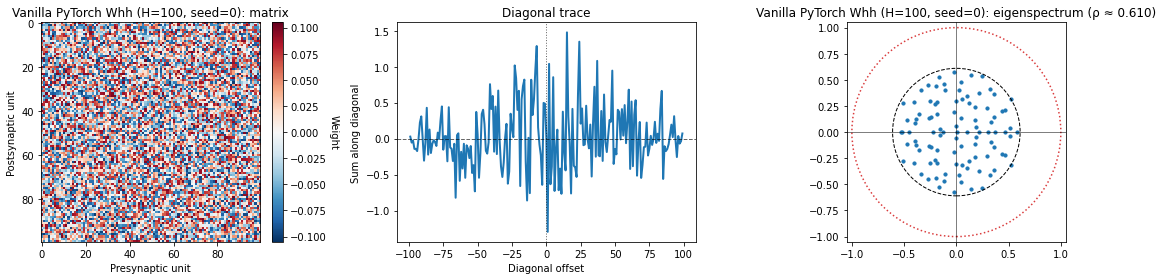

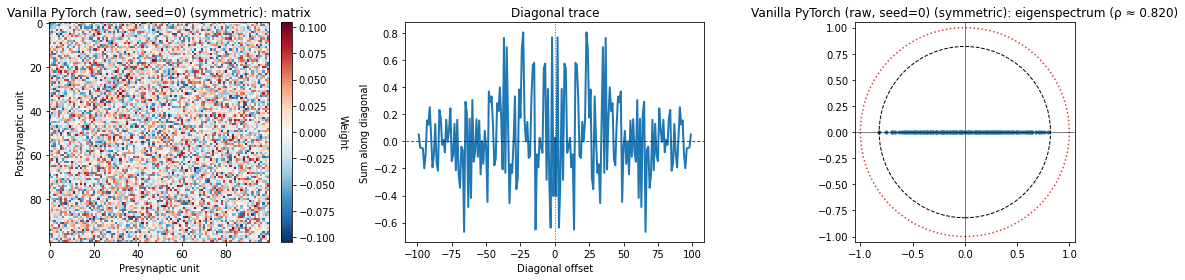

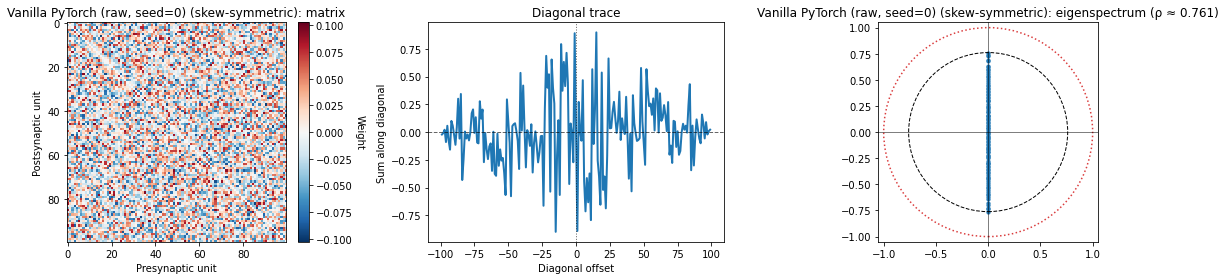

[vanilla] circulant? False (tol=1e-7)
Saved: ../data/hidden_weight_inits/dense/random_pytorch/seed000/Whh.npy and ../data/hidden_weight_inits/dense/random_pytorch/seed000/Whh.json

=== Vanilla PyTorch random, seed=1 ===
[vanilla] empirical var(Whh) ≈ 0.003324


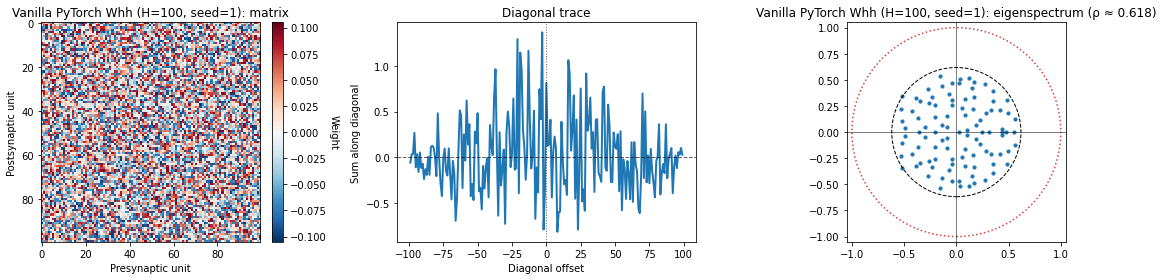

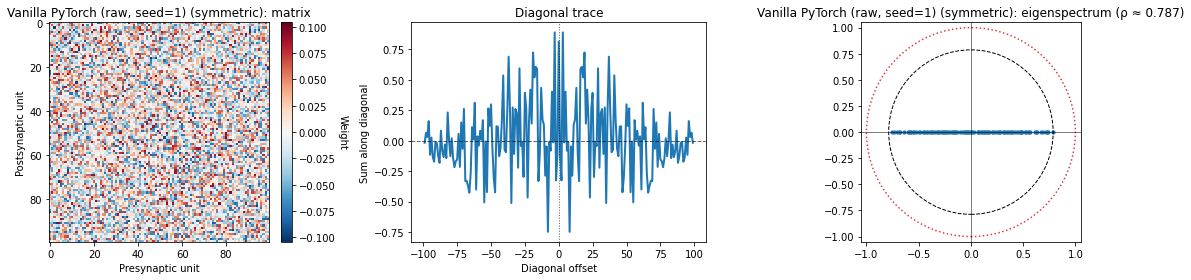

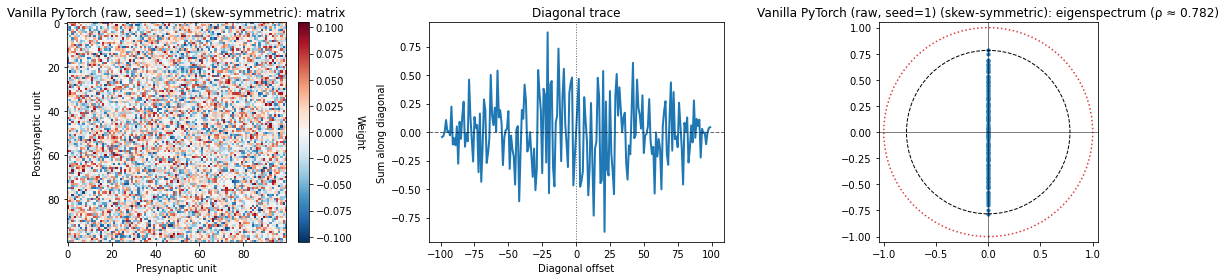

[vanilla] circulant? False (tol=1e-7)
Saved: ../data/hidden_weight_inits/dense/random_pytorch/seed001/Whh.npy and ../data/hidden_weight_inits/dense/random_pytorch/seed001/Whh.json

=== Vanilla PyTorch random, seed=2 ===
[vanilla] empirical var(Whh) ≈ 0.003305


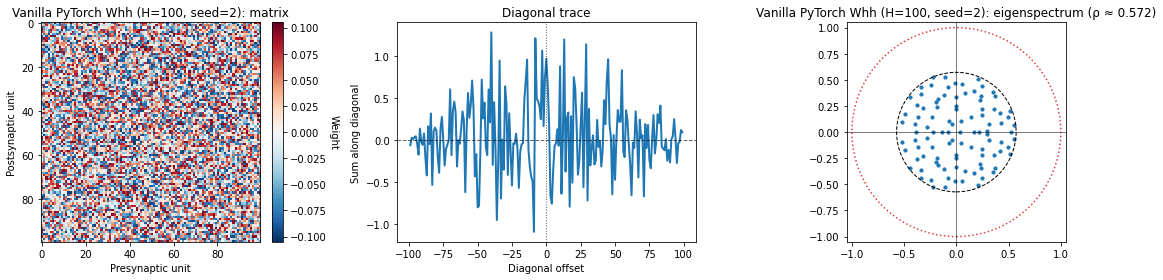

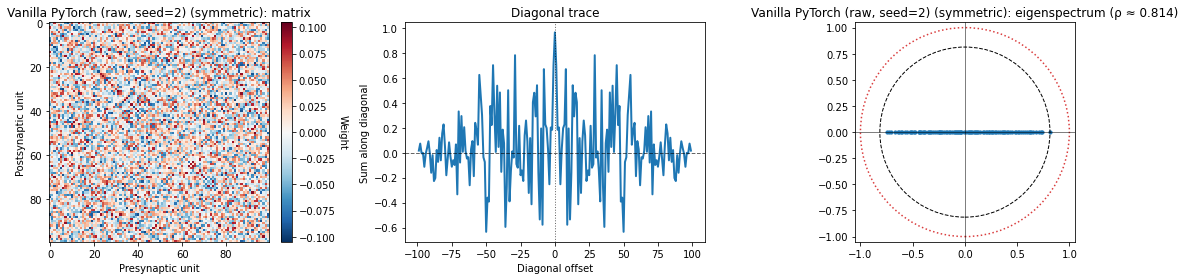

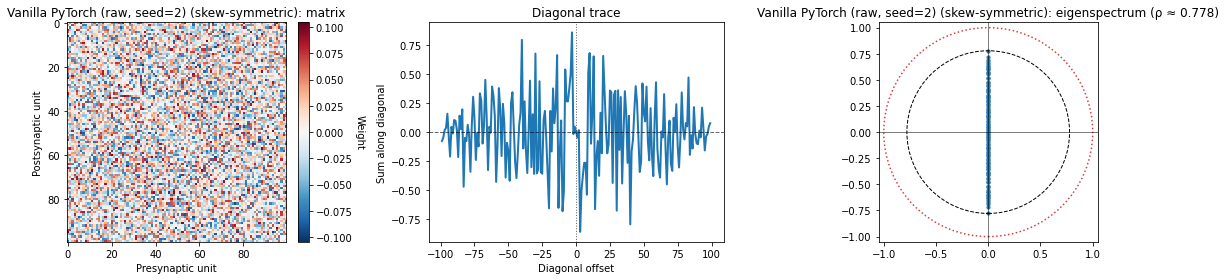

[vanilla] circulant? False (tol=1e-7)
Saved: ../data/hidden_weight_inits/dense/random_pytorch/seed002/Whh.npy and ../data/hidden_weight_inits/dense/random_pytorch/seed002/Whh.json

=== Vanilla PyTorch random, seed=3 ===
[vanilla] empirical var(Whh) ≈ 0.003362


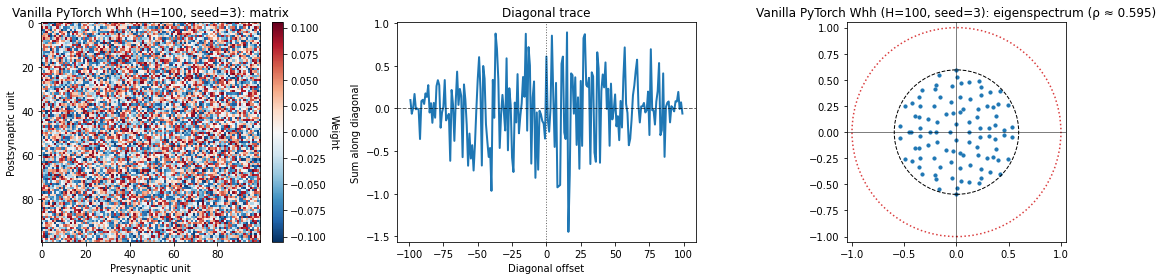

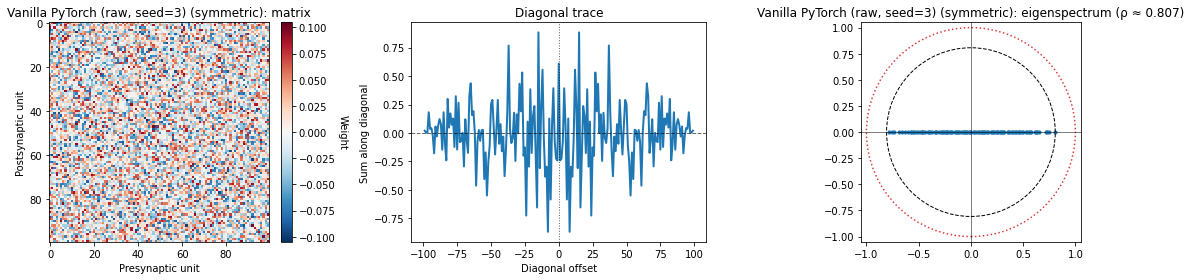

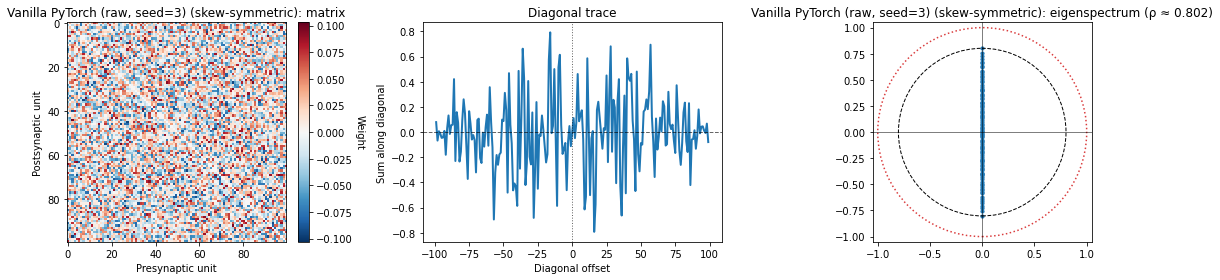

[vanilla] circulant? False (tol=1e-7)
Saved: ../data/hidden_weight_inits/dense/random_pytorch/seed003/Whh.npy and ../data/hidden_weight_inits/dense/random_pytorch/seed003/Whh.json

=== Vanilla PyTorch random, seed=4 ===
[vanilla] empirical var(Whh) ≈ 0.003357


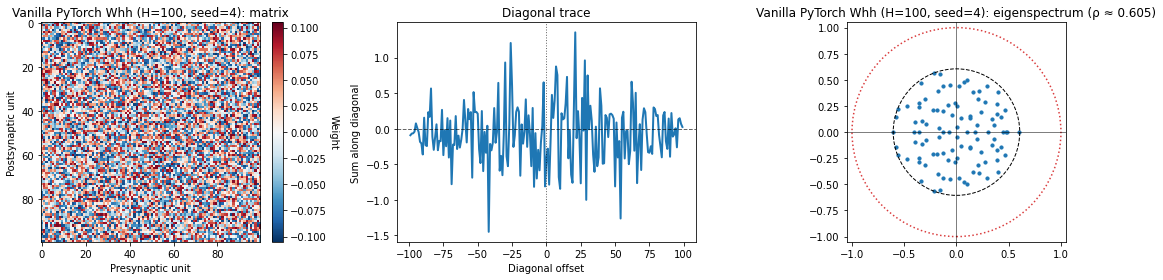

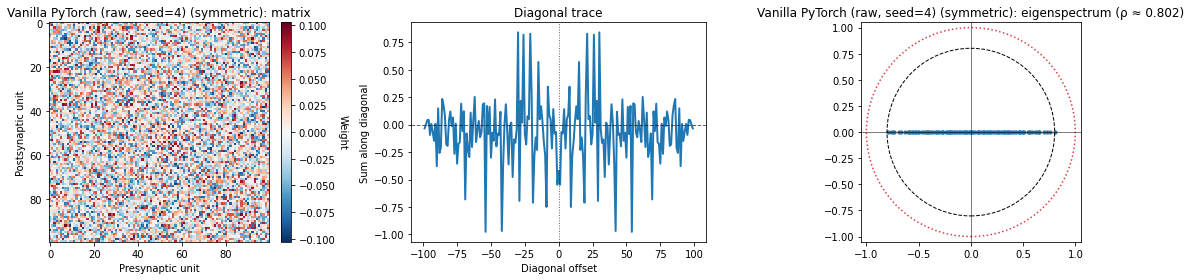

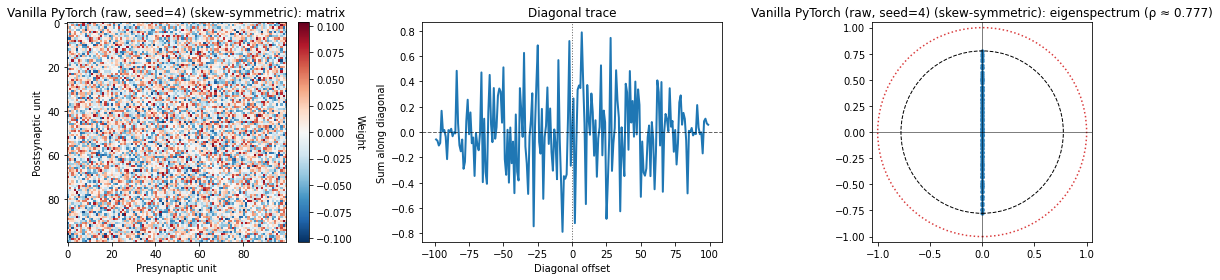

[vanilla] circulant? False (tol=1e-7)
Saved: ../data/hidden_weight_inits/dense/random_pytorch/seed004/Whh.npy and ../data/hidden_weight_inits/dense/random_pytorch/seed004/Whh.json


In [ ]:
# ------------------------------------------------
# Vanilla PyTorch random baseline
# ------------------------------------------------

seeds = [0]  # can add more seeds if desired

dense_root = "../data/hidden_weight_inits/random_pytorch"

for seed in seeds:
    print(f"\n=== Vanilla PyTorch random, seed={seed} ===")
    torch.manual_seed(seed)

    # Build model exactly as in training setup
    model = ElmanRNN(
        input_dim=H,
        hidden_dim=H,
        output_dim=H,
        rnn_act="tanh",
    )

    # Extract the dense hidden weight (PyTorch's default init)
    W_dense = model.rnn.weight_hh_l0.detach().cpu().numpy().astype(np.float32)
    emp_var = float(W_dense.var())
    print(f"[vanilla] empirical var(Whh) ≈ {emp_var:.6f}")

    # Plots
    hw.plot_weight_all(W_dense, title=f"Vanilla PyTorch Whh (H={H}, seed={seed})")
    hw.plot_sym_asym(W_dense, base_title=f"Vanilla PyTorch (raw, seed={seed})")

    # Check circulant-ness (it should be False for a generic random matrix)
    ok = hw.is_circulant(W_dense, tol=1e-7)
    print(f"[vanilla] circulant? {ok} (tol=1e-7)")

    # ---------- Save dense version ----------
    save_dir_dense = os.path.join(dense_root, f"seed{seed:03d}")
    fname_dense = "Whh"
    meta_dense = {
        "backend": "dense",
        "family": "vanilla_pytorch",
        "hidden_n": int(H),
        "seed": int(seed),
        "norm": "raw",  # Frobenius normalization happens in Main_clean.py
        "source": "nn.RNN.weight_hh_l0_default_init",
    }
    hw.save_matrix(W_dense, save_dir_dense, fname_dense, meta=meta_dense)

## Identity

INITIAL MATRICES


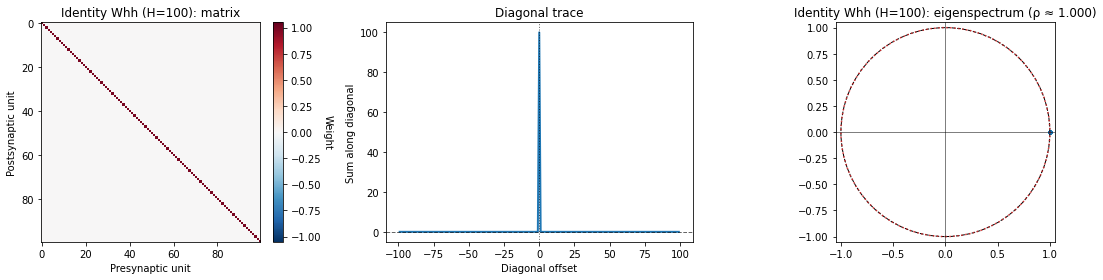

INITIAL SYMMETRY


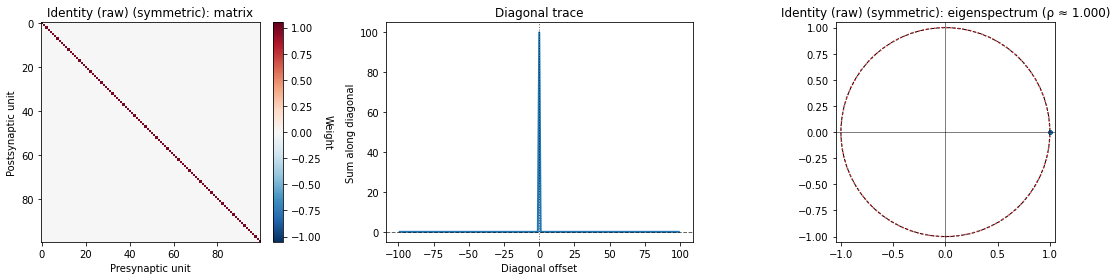

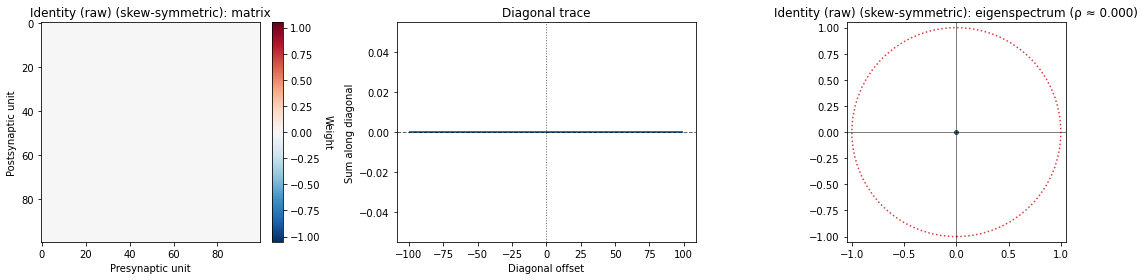

[builder] circulant? True (tol=1e-7)
Saved: ../data/hidden_weight_inits/identity/Whh.npy and ../data/hidden_weight_inits/identity/Whh.json


In [4]:
# --- identity matrix ---
W = bhw.build_shift(n=HIDDEN_N, value=1.0, offset=0, cyclic=True)

# quick plots
print("INITIAL MATRICES")
hw.plot_weight_all(W, title=f"Identity Whh (H={HIDDEN_N})")

# symmetry
print("INITIAL SYMMETRY")
hw.plot_sym_asym(W, base_title="Identity (raw)")

# verify circulant
ok = hw.is_circulant(W, tol=1e-7)
print("[builder] circulant? {} (tol=1e-7)".format(ok))
assert ok, "Expected a circulant matrix"

# save variants
dense_root = "../data/hidden_weight_inits/identity"

hw.save_matrix(
    W,
    dense_root,
    "Whh",
    meta={
        "backend": "dense",
        "family": "identity",
        "hidden_n": HIDDEN_N,
        "norm": "raw",
    },
)

## Cyclic shift

INITIAL MATRICES


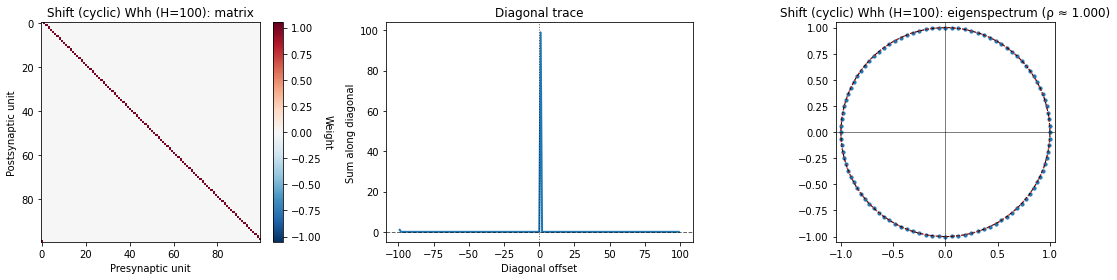

INITIAL SYMMETRY


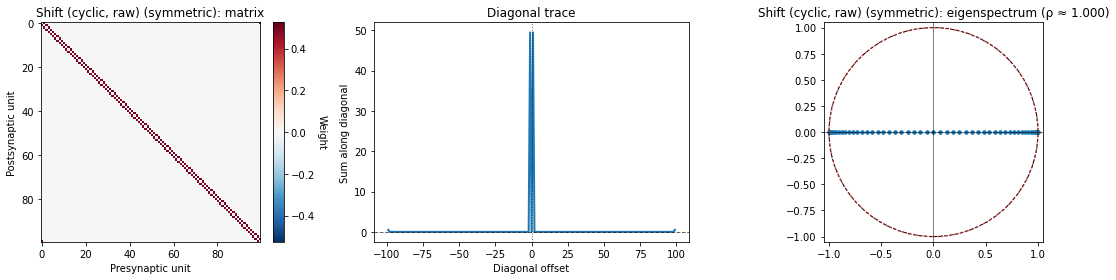

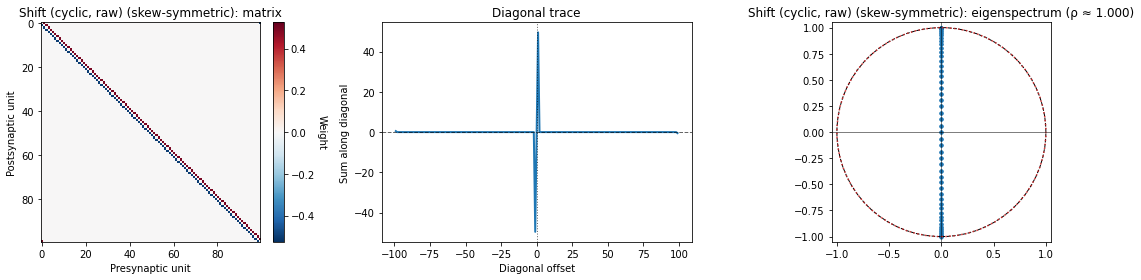

λ = 0.00


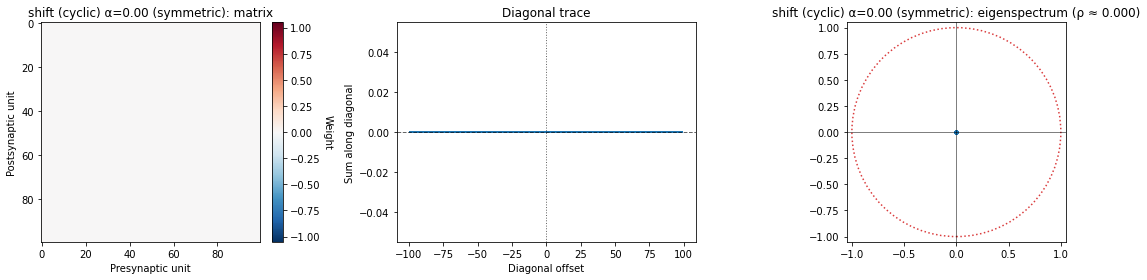

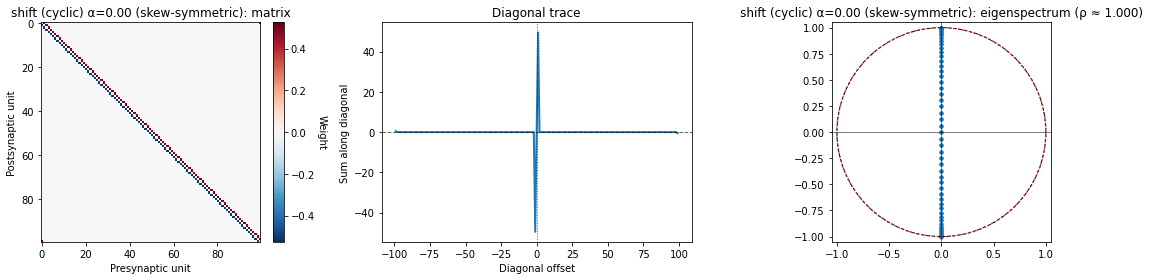

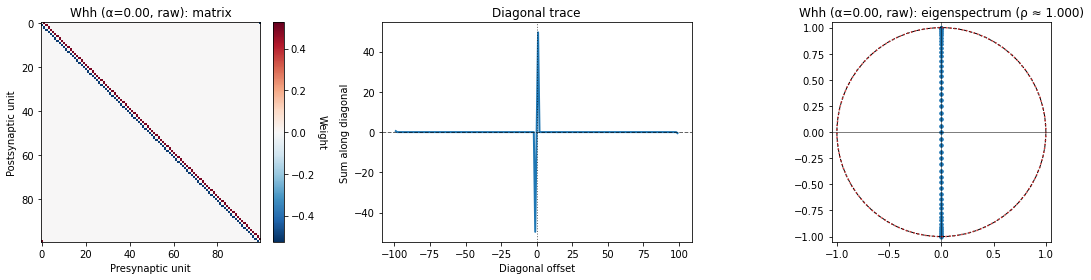

[builder] circulant? True (tol=1e-7)
Saved: ../data/hidden_weight_inits/cycshift/alphasym0p00/Whh.npy and ../data/hidden_weight_inits/cycshift/alphasym0p00/Whh.json
λ = 0.25


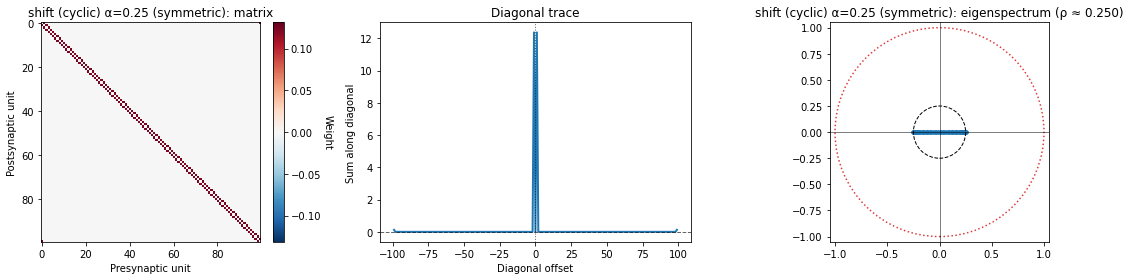

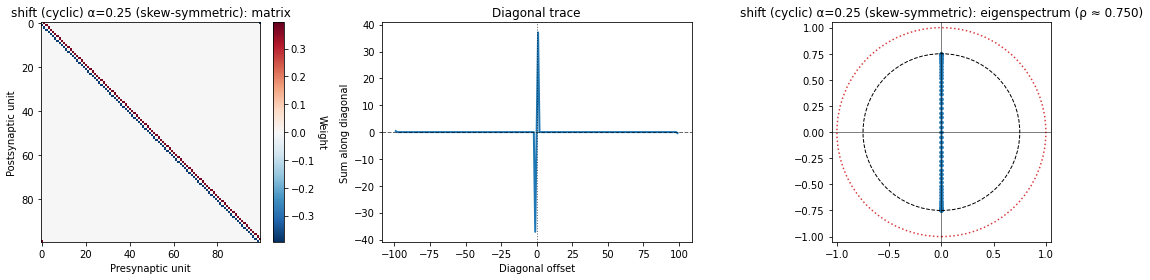

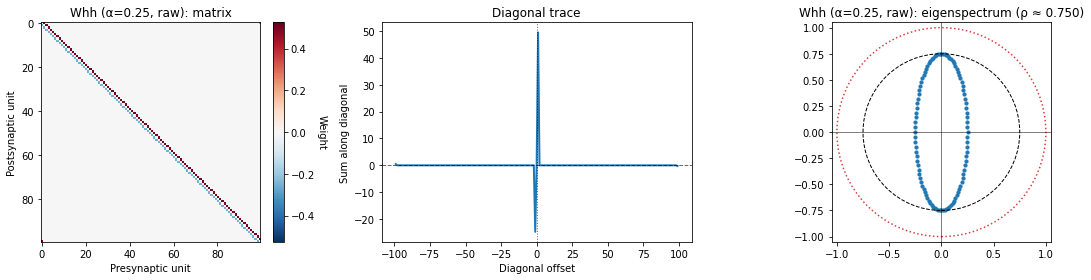

[builder] circulant? True (tol=1e-7)
Saved: ../data/hidden_weight_inits/cycshift/alphasym0p25/Whh.npy and ../data/hidden_weight_inits/cycshift/alphasym0p25/Whh.json
λ = 0.50


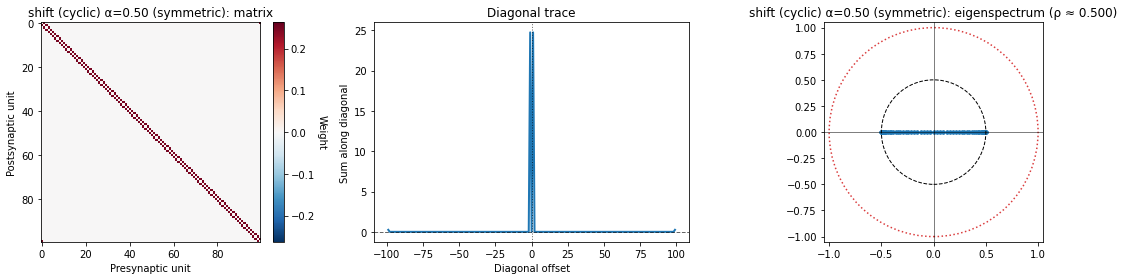

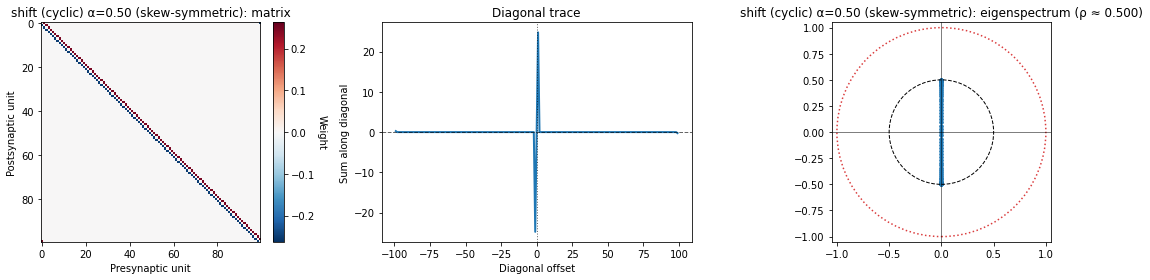

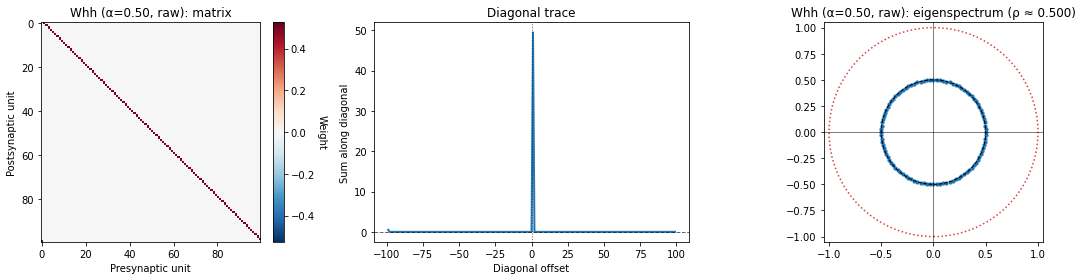

[builder] circulant? True (tol=1e-7)
Saved: ../data/hidden_weight_inits/cycshift/alphasym0p50/Whh.npy and ../data/hidden_weight_inits/cycshift/alphasym0p50/Whh.json
λ = 0.75


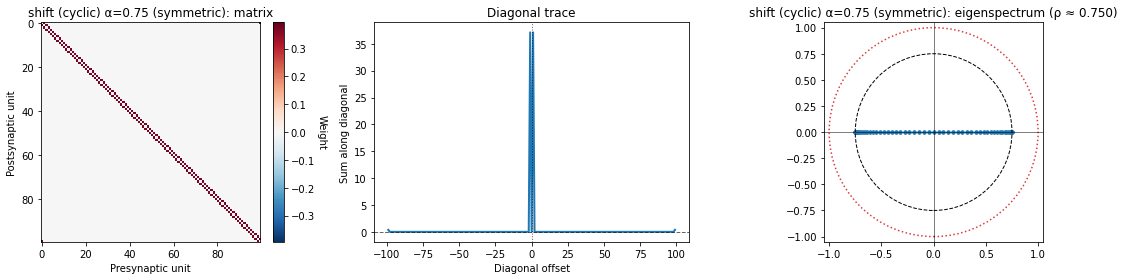

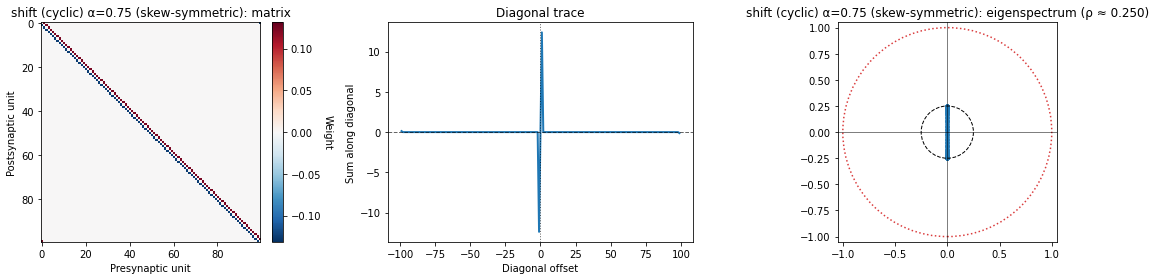

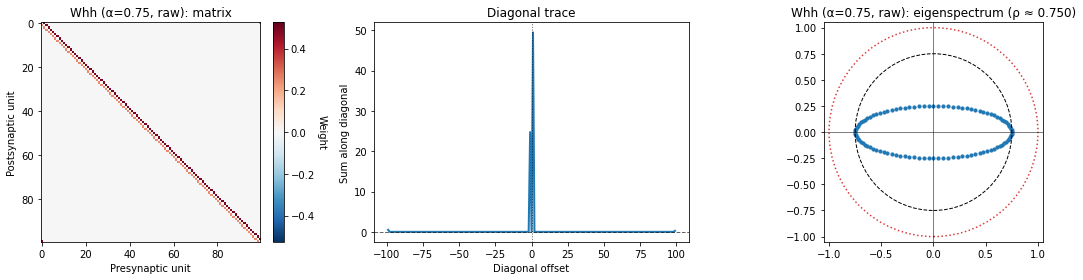

[builder] circulant? True (tol=1e-7)
Saved: ../data/hidden_weight_inits/cycshift/alphasym0p75/Whh.npy and ../data/hidden_weight_inits/cycshift/alphasym0p75/Whh.json
λ = 1.00


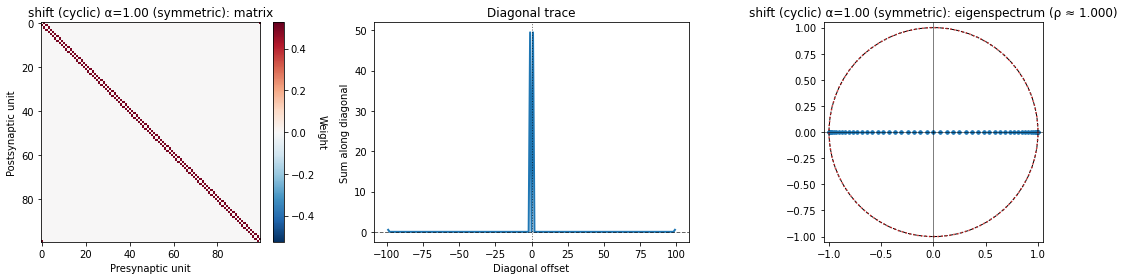

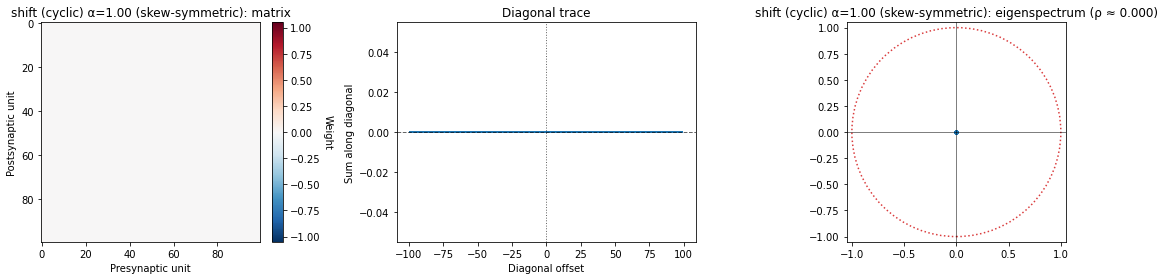

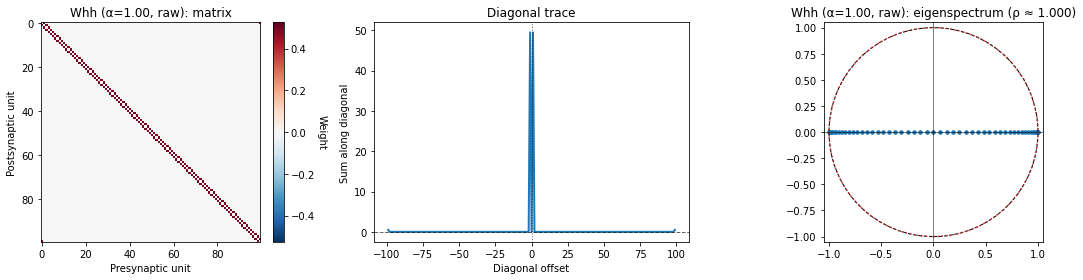

[builder] circulant? True (tol=1e-7)
Saved: ../data/hidden_weight_inits/cycshift/alphasym1p00/Whh.npy and ../data/hidden_weight_inits/cycshift/alphasym1p00/Whh.json


In [5]:
# --- shift (cyclic) matrix ---
W = bhw.build_shift(n=HIDDEN_N, value=1.0, offset=1, cyclic=True)

# quick plots
print("INITIAL MATRICES")
hw.plot_weight_all(W, title=f"Shift (cyclic) Whh (H={HIDDEN_N})")

# symmetry
print("INITIAL SYMMETRY")
hw.plot_sym_asym(W, base_title="Shift (cyclic, raw)")

# symmetric / skew-symmetric split
S = 0.5 * (W + W.T)
A = 0.5 * (W - W.T)

# choose mixing ratios you want
mix_ratios = [0.0, 0.25, 0.5, 0.75, 1.0]

# where to save this structure's init
dense_root = "../data/hidden_weight_inits/cycshift"

for alpha in mix_ratios:
    # alpha-blended hidden matrix: W_eff = αS + (1-α)A
    W_mix = alpha * S + (1 - alpha) * A

    # optional plots
    print(f"λ = {alpha:.2f}")
    hw.plot_sym_asym(W_mix, base_title=f"shift (cyclic) α={alpha:.2f}")
    hw.plot_weight_all(W_mix, title=f"Whh (α={alpha:.2f}, raw)")

    # verify circulant
    ok = hw.is_circulant(W_mix, tol=1e-7)
    print("[builder] circulant? {} (tol=1e-7)".format(ok))

    sub = mix_ratio_tag(alpha)

    # save under norm subfolders, with alpha subdir
    meta_dense = {
        "backend": "dense",
        "family": "shift",
        "geometry": "cyclic",
        "hidden_n": int(HIDDEN_N),
        "alpha": float(alpha),
        "decomposition": "W=αS+(1-α)A",
        "norm": "raw",  # Frobenius normalization happens in Main_clean.py
    }

    # ---- save dense Whh ----
    save_dir_dense = f"{dense_root}/alpha{sub}"
    fname_dense = "Whh"
    hw.save_matrix(
        W_mix,
        save_dir_dense,
        fname_dense,
        meta=meta_dense,
    )